# Telecom Customer Analytics Project
## Step 1: Import Libraries and Load Dataset

In [52]:
import pandas as pd
import numpy as np
field_Description = pd.read_excel("Field Descriptions.xlsx")
telecom_data = pd.read_excel("telecom_data_sample.xlsx")

field_Description.head()
telecom_data.head()


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770,2019-04-25 14:35:31,662,1823652,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,15854611,2501332,8198936,9656251,278082303,14344150,171744450,8814393,36749741,308879636
1,13114483482878900224,2019-04-09 13:04:04,235,2019-04-25 08:15:48,606,1365104,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,20247395,19111729,18338413,17227132,608750074,1170709,526904238,15055145,53800391,653384965
2,13114483484080500736,2019-04-09 17:42:11,1,2019-04-25 11:58:13,652,1361762,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,19725661,14699576,17587794,6163408,229584621,395630,410692588,4215763,27883638,279807335
3,13114483485442799616,2019-04-10 00:31:25,486,2019-04-25 07:36:35,171,1321509,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,21388122,15146643,13994646,1097942,799538153,10849722,749039933,12797283,43324218,846028530
4,13114483499480700928,2019-04-12 20:10:23,565,2019-04-25 10:40:32,954,1089009,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,15259380,18962873,17124581,415218,527707248,3529801,550709500,13910322,38542814,569138589


## Step 2: Understanding the Dataset


In [3]:
telecom_data.shape
telecom_data.info()
telecom_data.isnull().sum().sort_values(ascending=False)



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Bearer Id                                 10000 non-null  object        
 1   Start                                     10000 non-null  datetime64[us]
 2   Start ms                                  10000 non-null  int64         
 3   End                                       10000 non-null  datetime64[us]
 4   End ms                                    10000 non-null  int64         
 5   Dur. (ms)                                 10000 non-null  int64         
 6   IMSI                                      9955 non-null   float64       
 7   MSISDN/Number                             9914 non-null   float64       
 8   IMEI                                      9955 non-null   float64       
 9   Last Location Name                      

Nb of sec with 37500B < Vol UL              7809
Nb of sec with 6250B < Vol UL < 37500B      5802
Nb of sec with 125000B < Vol DL             4373
TCP UL Retrans. Vol (Bytes)                 4356
Nb of sec with 31250B < Vol DL < 125000B    4032
Nb of sec with 1250B < Vol UL < 6250B       3982
Nb of sec with 6250B < Vol DL < 31250B      3548
TCP DL Retrans. Vol (Bytes)                 3524
HTTP UL (Bytes)                             2904
HTTP DL (Bytes)                             2858
Avg RTT DL (ms)                              746
Avg RTT UL (ms)                              743
MSISDN/Number                                 86
Last Location Name                            81
Nb of sec with Vol UL < 1250B                 79
UL TP < 10 Kbps (%)                           79
10 Kbps < UL TP < 50 Kbps (%)                 79
UL TP > 300 Kbps (%)                          79
50 Kbps < UL TP < 300 Kbps (%)                79
DL TP > 1 Mbps (%)                            71
50 Kbps < DL TP < 25

## Step 3: Data Cleaning


In [4]:
# checking the duplicates 
telecom_data.duplicated().sum()

np.int64(0)

### Interpretation

There are no duplicate records in the telecom dataset. Therefore, no duplicate rows need to be removed before further analysis.


### 3.1 Check Data Types

In [5]:
telecom_data.dtypes

Bearer Id                                           object
Start                                       datetime64[us]
Start ms                                             int64
End                                         datetime64[us]
End ms                                               int64
Dur. (ms)                                            int64
IMSI                                               float64
MSISDN/Number                                      float64
IMEI                                               float64
Last Location Name                                  object
Avg RTT DL (ms)                                    float64
Avg RTT UL (ms)                                    float64
Avg Bearer TP DL (kbps)                              int64
Avg Bearer TP UL (kbps)                              int64
TCP DL Retrans. Vol (Bytes)                        float64
TCP UL Retrans. Vol (Bytes)                        float64
DL TP < 50 Kbps (%)                                float

### Interpretation

The dataset contains three main data types:
- **float64**: Numerical variables such as download, upload, duration, and throughput.
- **object/string**: Categorical variables such as handset manufacturer and handset type.
- **datetime**: Date and time variables such as Start and End.

Understanding the data types helps us apply the appropriate data cleaning techniques to each type of column.

### 3.2 Create a Backup Copy of the Dataset

In [6]:
telecom_clean = telecom_data.copy()


A copy of the original dataset is created before cleaning so that the original data remains unchanged. This allows us to return to the raw dataset if needed.

### 3.3 Identifying the numerical columns


In [7]:
# Identifying the numerical columns

numeric_columns = telecom_clean.select_dtypes(include=['float64', 'int64']).columns

numeric_columns

Index(['Start ms', 'End ms', 'Dur. (ms)', 'IMSI', 'MSISDN/Number', 'IMEI',
       'Avg RTT DL (ms)', 'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)',
       'Avg Bearer TP UL (kbps)', 'TCP DL Retrans. Vol (Bytes)',
       'TCP UL Retrans. Vol (Bytes)', 'DL TP < 50 Kbps (%)',
       '50 Kbps < DL TP < 250 Kbps (%)', '250 Kbps < DL TP < 1 Mbps (%)',
       'DL TP > 1 Mbps (%)', 'UL TP < 10 Kbps (%)',
       '10 Kbps < UL TP < 50 Kbps (%)', '50 Kbps < UL TP < 300 Kbps (%)',
       'UL TP > 300 Kbps (%)', 'HTTP DL (Bytes)', 'HTTP UL (Bytes)',
       'Activity Duration DL (ms)', 'Activity Duration UL (ms)', 'Dur. (ms).1',
       'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',
       'Nb of sec with Vol DL < 6250B', 'Nb of sec with Vol UL < 1250B',
       'Social Media DL (

### Interpretation

The numeric columns in the dataset have been identified successfully. These columns will be used to replace missing values with the mean, ensuring that only numerical features are modified while text and datetime columns remain unchanged.

###  3.4 Replace Missing Values with Mean

In [8]:
# Replace Missing Values with Mean
telecom_clean[numeric_columns] = telecom_clean[numeric_columns].fillna(
    telecom_clean[numeric_columns].mean() 
)



### Verify that the missing values were filled 

In [9]:
telecom_clean.isnull().sum().sort_values(ascending=False)


Last Location Name                          81
Handset Type                                45
Handset Manufacturer                        45
End                                          0
End ms                                       0
Start                                        0
Bearer Id                                    0
IMSI                                         0
MSISDN/Number                                0
IMEI                                         0
Avg RTT DL (ms)                              0
Avg RTT UL (ms)                              0
Avg Bearer TP DL (kbps)                      0
Avg Bearer TP UL (kbps)                      0
TCP DL Retrans. Vol (Bytes)                  0
TCP UL Retrans. Vol (Bytes)                  0
DL TP < 50 Kbps (%)                          0
50 Kbps < DL TP < 250 Kbps (%)               0
250 Kbps < DL TP < 1 Mbps (%)                0
DL TP > 1 Mbps (%)                           0
UL TP < 10 Kbps (%)                          0
Dur. (ms)    

### Interpretation

The missing values in all numerical columns have been successfully replaced using the mean of their respective columns.

The remaining missing values belong to categorical (text) columns and datetime columns. These require different treatment because replacing text or dates with a numerical mean is not appropriate.

### Step 3.6: Replace Missing Values in Categorical Columns with Mode

In [10]:
categorical_columns = telecom_clean.select_dtypes(include=['object']).columns

categorical_columns

C:\Users\USER\AppData\Local\Temp\ipykernel_17140\3175511889.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = telecom_clean.select_dtypes(include=['object']).columns


Index(['Bearer Id', 'Last Location Name', 'Handset Manufacturer',
       'Handset Type'],
      dtype='str')

### Fill Missing Values with Mode

In [11]:
for column in categorical_columns:
    telecom_clean[column] = telecom_clean[column].fillna(
        telecom_clean[column].mode()[0]
    )

telecom_clean.isnull().sum().sort_values(ascending=False)

Bearer Id                                   0
Start                                       0
Start ms                                    0
End                                         0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### 3.7 Handle Missing Datetime Values

In [12]:
telecom_clean.dropna(subset=['Start', 'End'], inplace=True)
telecom_clean.isnull().sum().sort_values(ascending=False)


Bearer Id                                   0
Start                                       0
Start ms                                    0
End                                         0
End ms                                      0
Dur. (ms)                                   0
IMSI                                        0
MSISDN/Number                               0
IMEI                                        0
Last Location Name                          0
Avg RTT DL (ms)                             0
Avg RTT UL (ms)                             0
Avg Bearer TP DL (kbps)                     0
Avg Bearer TP UL (kbps)                     0
TCP DL Retrans. Vol (Bytes)                 0
TCP UL Retrans. Vol (Bytes)                 0
DL TP < 50 Kbps (%)                         0
50 Kbps < DL TP < 250 Kbps (%)              0
250 Kbps < DL TP < 1 Mbps (%)               0
DL TP > 1 Mbps (%)                          0
UL TP < 10 Kbps (%)                         0
10 Kbps < UL TP < 50 Kbps (%)     

### Data Cleaning Summary

The telecom dataset was cleaned using the following steps:

- Checked for duplicate records (no duplicates found).
- Identified data types of all columns.
- Created a backup copy of the original dataset.
- Replaced missing values in numerical columns using the mean.
- Replaced missing values in categorical columns using the mode.
- Removed rows containing missing datetime values.
- Verified that no missing values remained after cleaning.

The dataset is now clean and ready for Exploratory Data Analysis (EDA).

## 4: Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics

In [13]:
telecom_clean.describe()

,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Avg RTT DL (ms),Avg RTT UL (ms),...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
count,10000,10000.000000,10000,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.000000,...,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,2019-04-24 06:49:39.346100,498.652400,2019-04-25 01:40:19.960800,497.978000,6.784005e+04,2.082017e+14,3.367591e+10,5.222416e+13,131.831316,20.167225,...,1.156697e+07,1.093792e+07,1.159491e+07,1.086662e+07,4.201976e+08,8.252164e+06,4.206466e+08,8.335074e+06,4.095209e+07,4.527532e+08
min,2019-04-04 12:01:18,0.000000,2019-04-24 23:00:04,0.000000,2.295800e+04,2.082001e+14,3.360107e+10,1.247901e+12,6.000000,0.000000,...,1.224000e+03,1.050000e+02,1.136000e+03,2.430000e+02,1.251100e+04,1.394000e+03,4.236660e+05,1.905000e+03,6.243519e+06,7.114041e+06
25%,2019-04-24 02:44:04.750000,250.000000,2019-04-25 00:22:23.750000,251.000000,4.158475e+04,2.082014e+14,3.365817e+10,3.552141e+13,38.000000,4.000000,...,5.669677e+06,5.505214e+06,5.695370e+06,5.381031e+06,2.115701e+08,4.063424e+06,2.089014e+08,4.189338e+06,3.288391e+07,2.459591e+08
50%,2019-04-24 09:13:03,497.000000,2019-04-25 01:18:16.500000,498.000000,5.775800e+04,2.082015e+14,3.366414e+10,3.575751e+13,55.000000,9.000000,...,1.152480e+07,1.078695e+07,1.155351e+07,1.073990e+07,4.204656e+08,8.229242e+06,4.242242e+08,8.342401e+06,4.083175e+07,4.526578e+08
75%,2019-04-24 13:55:15,747.250000,2019-04-25 02:41:31.500000,743.000000,8.639900e+04,2.082018e+14,3.368290e+10,8.637690e+13,104.000000,20.167225,...,1.750616e+07,1.643212e+07,1.734177e+07,1.627824e+07,6.317820e+08,1.241018e+07,6.289928e+08,1.246929e+07,4.895531e+07,6.633708e+08
max,2019-04-24 16:41:00,999.000000,2019-04-25 23:57:10,999.000000,1.823652e+06,2.082099e+14,3.378998e+10,9.900120e+13,54847.000000,5279.000000,...,2.325829e+07,2.201196e+07,2.325798e+07,2.200974e+07,8.434419e+08,1.655607e+07,8.433458e+08,1.655667e+07,7.391670e+07,8.964337e+08
std,NaN,288.279077,NaN,285.872685,6.188302e+04,1.309472e+09,4.451077e+07,2.418055e+13,738.071636,79.103459,...,6.758998e+06,6.314766e+06,6.696971e+06,6.320848e+06,2.435583e+08,4.814455e+06,2.413300e+08,4.772618e+06,1.123271e+07,2.436977e+08


### Interpretation

The summary statistics provide an overview of the numerical variables in the telecom dataset.

- The dataset contains **150,000 cleaned observations**.
- The mean values represent the average customer usage for each numerical variable.
- The standard deviation indicates considerable variability in customer behavior.
- The minimum and maximum values show that some variables contain extremely large values, suggesting possible outliers.
- The quartiles (25%, 50%, and 75%) describe the distribution of the data and provide insight into the spread of customer usage.
- Overall, the dataset is ready for visualization and deeper exploratory analysis.

## 4.2 Distribution of Session Duration

A histogram is used to visualize the distribution of session duration. It helps us understand how frequently different session durations occur and whether the data is normally distributed or skewed.

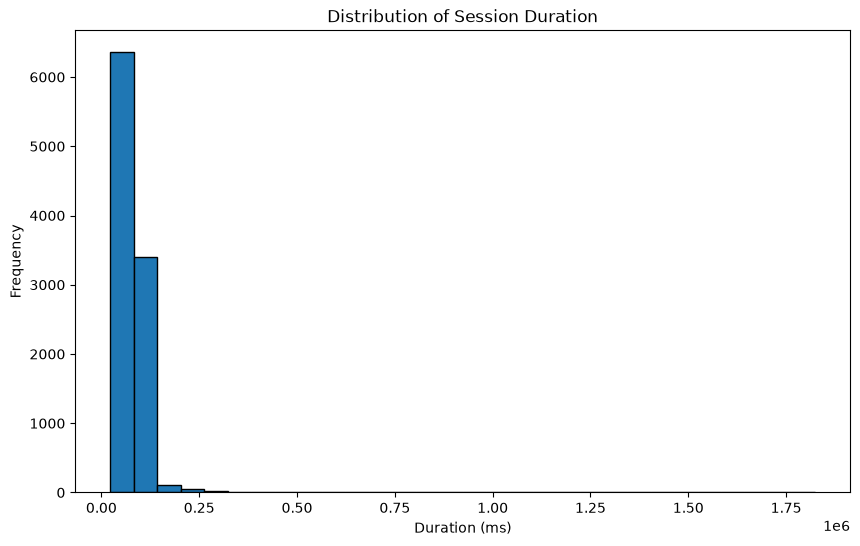

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(telecom_clean['Dur. (ms)'], bins=30, edgecolor='black')

plt.title('Distribution of Session Duration')
plt.xlabel('Duration (ms)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

The histogram shows the distribution of customer session duration.

- Most telecom sessions are concentrated within shorter durations.
- The distribution is positively (right) skewed, indicating that a small number of customers have significantly longer session durations.
- A few extreme values are visible, suggesting the presence of heavy users or outliers.
- The data is not normally distributed, which is common in telecom usage datasets.


## 4.3 Box Plot of Session Duration

A box plot is used to identify the spread of the data and detect potential outliers. It summarizes the distribution using the median, quartiles, and extreme values.

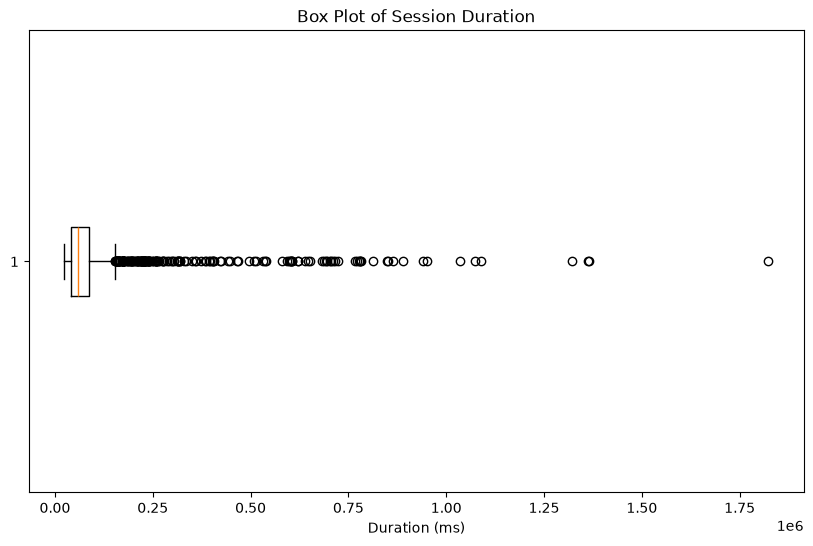

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(telecom_clean['Dur. (ms)'], orientation='horizontal') 

plt.title('Box Plot of Session Duration')
plt.xlabel('Duration (ms)')

plt.show()

### Interpretation

The box plot indicates that session duration contains a large number of outliers. Most customer sessions are concentrated within a relatively small range, while a few sessions have exceptionally long durations. This suggests that the distribution is positively skewed and that some users spend significantly more time on the network than the average customer. 

### 4.4: Histogram of Total Download (Bytes)

### Why are we plotting this?

A histogram of Total Download (Bytes) helps us understand how internet download usage is distributed among customers. It shows whether most customers download similar amounts of data or whether a few customers consume significantly higher amounts.

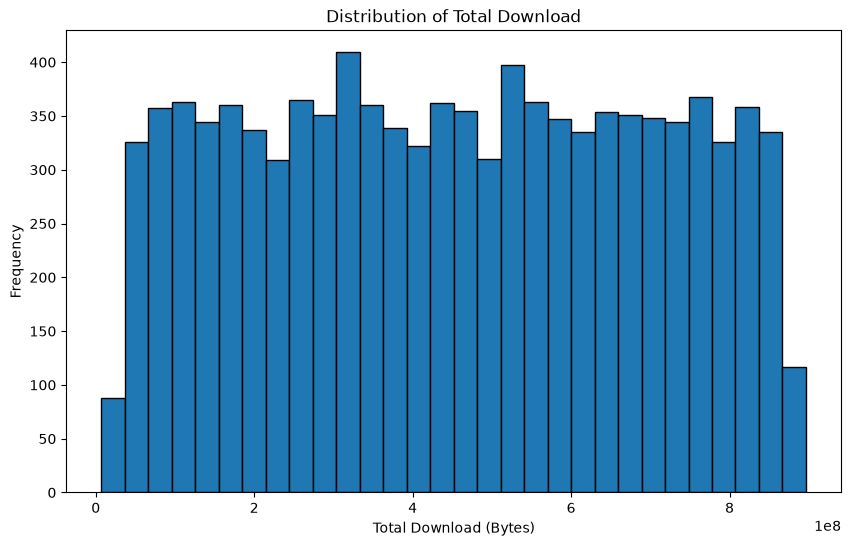

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(telecom_clean['Total DL (Bytes)'],
         bins=30,
         edgecolor='black')

plt.title("Distribution of Total Download")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The histogram shows that Total Download (Bytes) is fairly evenly distributed across the dataset. Unlike session duration, download usage does not exhibit a strong positive skew. Customers are spread across different download usage levels, indicating a wide variety of internet consumption patterns.

## 4.5 Box Plot of Total Download


A box plot summarizes the distribution of Total Download (Bytes) and helps identify potential outliers among customers with unusually high or low download usage.

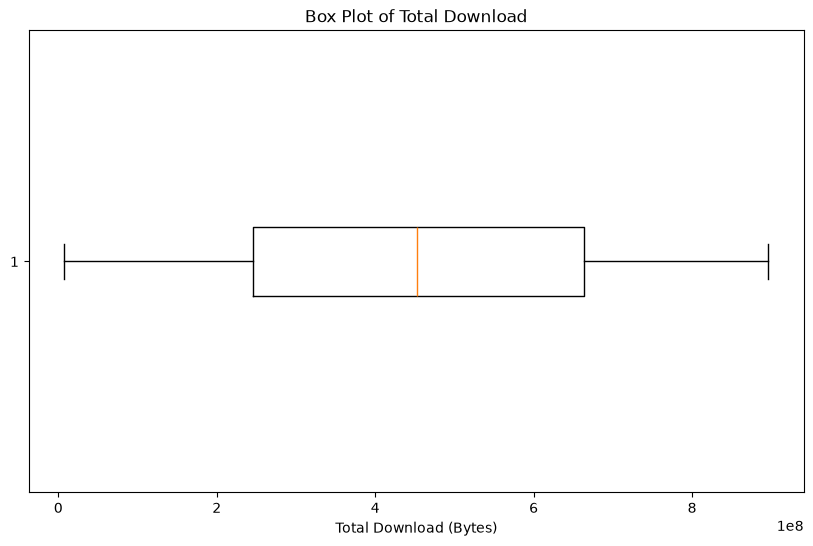

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.boxplot(
    telecom_clean['Total DL (Bytes)'],
    orientation='horizontal'
)

plt.title("Box Plot of Total Download")
plt.xlabel("Total Download (Bytes)")

plt.show()

### Interpretation

The box plot shows that Total Download (Bytes) is fairly evenly distributed with no significant outliers. The median is positioned near the center of the box, indicating a balanced distribution. The spread of the data suggests that customers have a wide range of download usage, but there are no unusually extreme download values.

### 4.4 Correlation Heatmap 


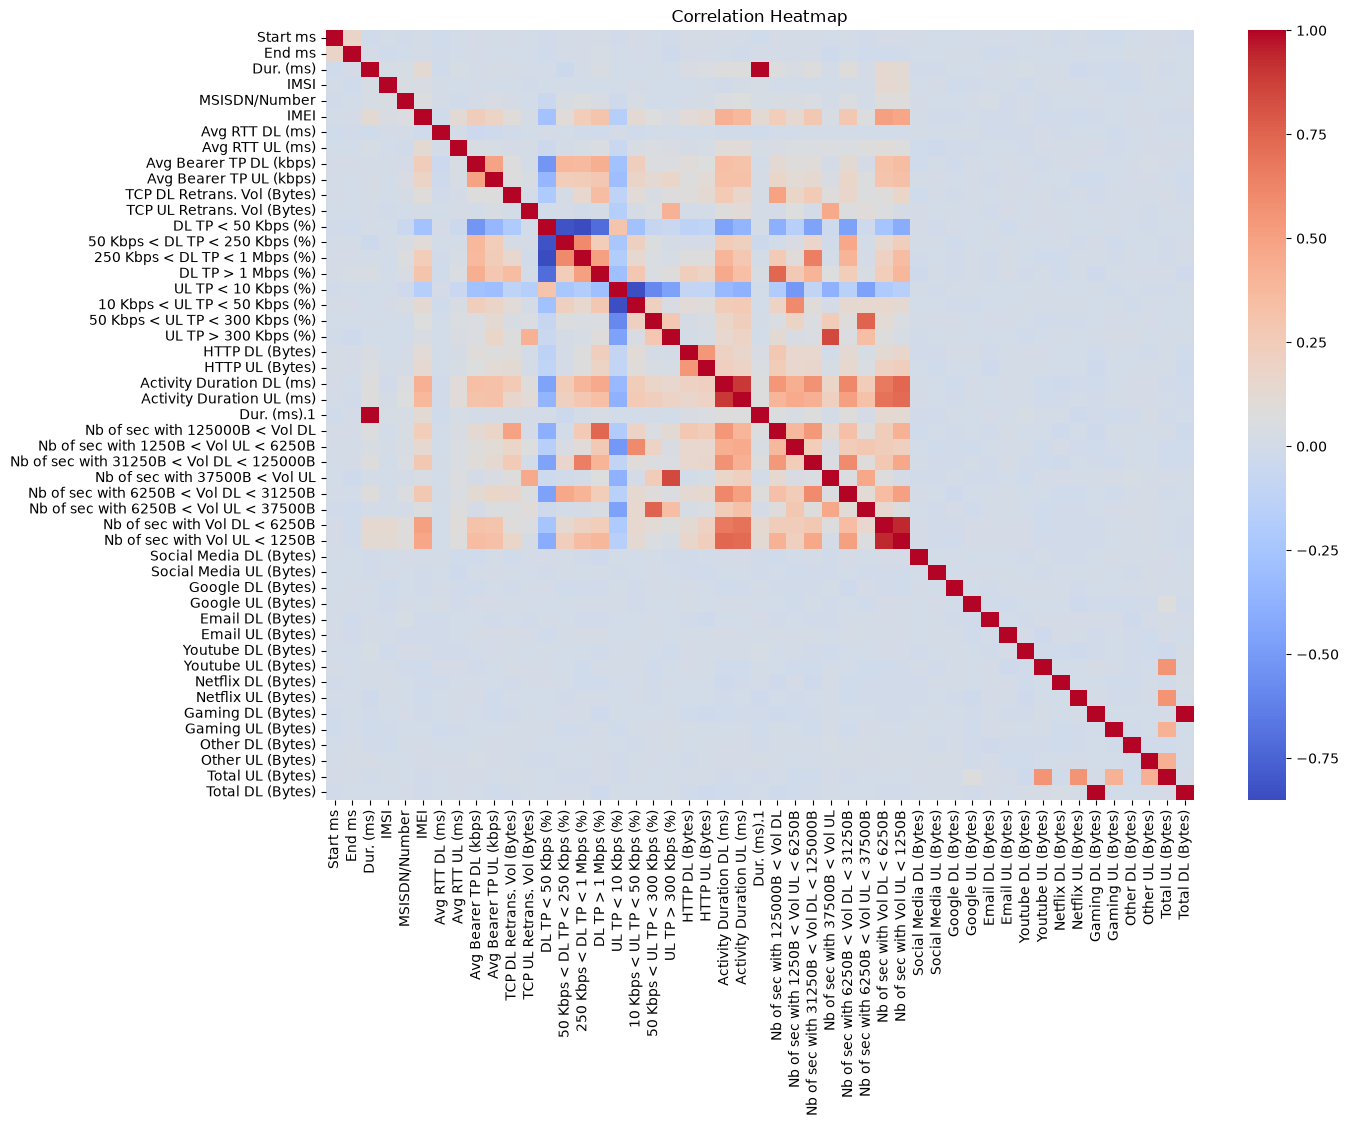

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    telecom_clean.select_dtypes(include=['float64','int64']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- The heatmap displays the correlation between all numerical variables.
- Dark red colors indicate a strong positive correlation.
- Dark blue colors indicate a strong negative correlation.
- Light colors indicate little or no correlation.
- Most variables show weak to moderate correlations, while a few download and upload-related variables have stronger positive relationships.
- The heatmap helps identify important features for further analysis and predictive modeling.

## 4.5 Scatter Plot: Total Download vs Total Upload

A scatter plot is used to visualize the relationship between two numerical variables. It helps identify positive or negative correlations, clusters, and unusual observations.

Here, we compare Total Download (Bytes) with Total Upload (Bytes) to understand whether customers with higher download usage also tend to have higher upload usage.

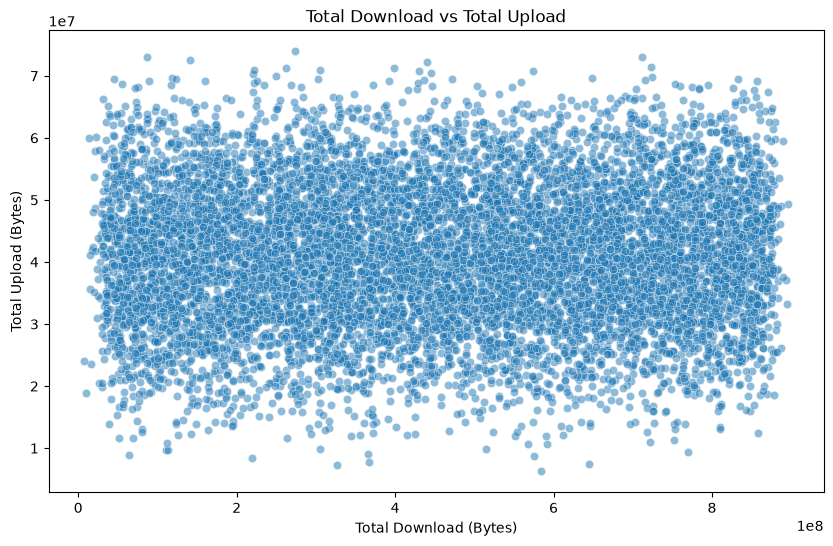

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=telecom_clean['Total DL (Bytes)'],
    y=telecom_clean['Total UL (Bytes)'],
    alpha=0.5
)

plt.title("Total Download vs Total Upload")
plt.xlabel("Total Download (Bytes)")
plt.ylabel("Total Upload (Bytes)")

plt.show()

### Interpretation:

The scatter plot compares Total Download (Bytes) and Total Upload (Bytes).
The data points are widely scattered across the graph.
There is no clear linear relationship between download and upload traffic.
This suggests that customers with higher download usage do not necessarily have higher upload usage.
Further statistical analysis (such as the correlation coefficient) would be needed to measure the strength of the relationship.

## 4.6 Top 3 Handset Manufacturers

In [20]:
# Find the top 3 handset manufacturers
top_manufacturers = telecom_clean['Handset Manufacturer'].value_counts().head(3)

top_manufacturers

Handset Manufacturer
Apple      3943
Huawei     3036
Samsung    2039
Name: count, dtype: int64

## 4.7 Top 10 Handset Manufacturers

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Huawei B528S-23A'),
  Text(1, 0, 'Apple iPhone 6 (A1586)'),
  Text(2, 0, 'Apple iPhone 6S (A1688)'),
  Text(3, 0, 'Apple iPhone 7 (A1778)'),
  Text(4, 0, 'undefined'),
  Text(5, 0, 'Apple iPhone 8 (A1905)'),
  Text(6, 0, 'Apple iPhone Se (A1723)'),
  Text(7, 0, 'Apple iPhone Xr (A2105)'),
  Text(8, 0, 'Apple iPhone X (A1901)'),
  Text(9, 0, 'Samsung Galaxy S8 (Sm-G950F)')])

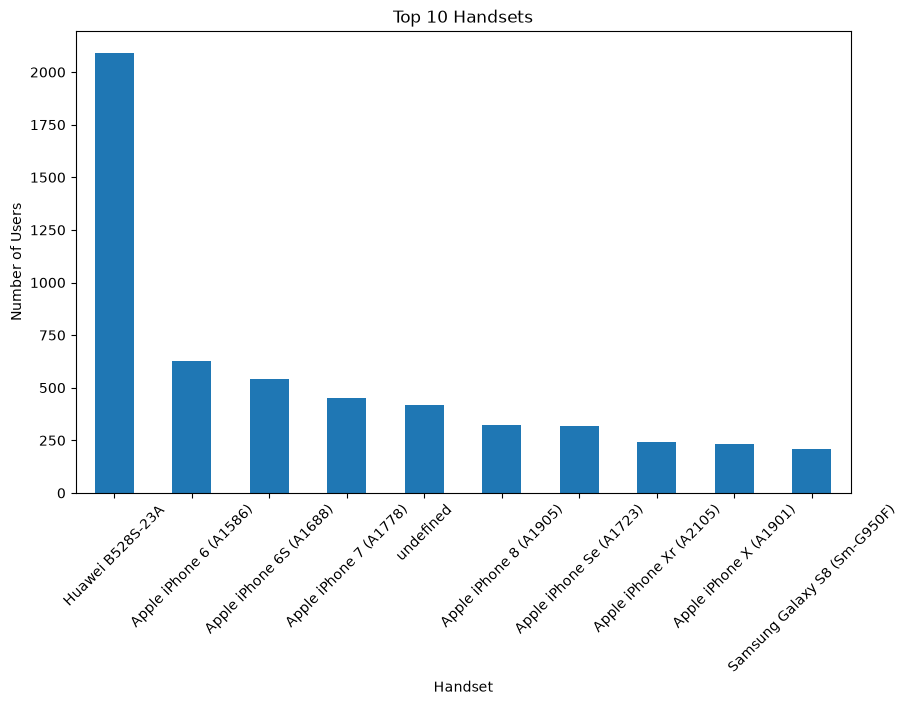

In [21]:
import matplotlib.pyplot as plt

top_handsets = telecom_clean['Handset Type'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_handsets.plot(kind='bar')

plt.title('Top 10 Handsets')
plt.xlabel('Handset')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)


### Interpretation:

The analysis identifies the ten most frequently used handset models among customers. Huawei B528S-23A is the most widely used handset, followed by several Apple iPhone models. This indicates that customer device usage is concentrated among a relatively small number of handset models. These insights can help the telecom company optimize network compatibility, customer support, and targeted marketing for the most commonly used devices.

##  4.8 Top 5 Handsets per Top 3 Manufacturers

In [22]:
# Top 5 handsets for each of the top 3 manufacturers

top_manufacturers = telecom_clean['Handset Manufacturer'].value_counts().head(3).index

for manufacturer in top_manufacturers:
    top_handsets = (
        telecom_clean[telecom_clean['Handset Manufacturer'] == manufacturer]
        ['Handset Type']
        .value_counts()
        .head(5)
    )
    
    print(f"\nTop 5 Handsets for {manufacturer}:")
    print(top_handsets)


Top 5 Handsets for Apple:
Handset Type
Apple iPhone 6 (A1586)     628
Apple iPhone 6S (A1688)    541
Apple iPhone 7 (A1778)     449
Apple iPhone 8 (A1905)     325
Apple iPhone Se (A1723)    319
Name: count, dtype: int64

Top 5 Handsets for Huawei:
Handset Type
Huawei B528S-23A                  2046
Huawei E5180                       209
Huawei P20 Lite Huawei Nova 3E     116
Huawei P20                          82
Huawei Y6 2018                      61
Name: count, dtype: int64

Top 5 Handsets for Samsung:
Handset Type
Samsung Galaxy S8 (Sm-G950F)    211
Samsung Galaxy A5 Sm-A520F      163
Samsung Galaxy S7 (Sm-G930X)    150
Samsung Galaxy J3 (Sm-J330)     140
Samsung Galaxy J5 (Sm-J530)     125
Name: count, dtype: int64


### Interpretation:
The analysis identifies the top 5 most frequently used handset models for each of the top 3 handset manufacturers: Apple, Huawei, and Samsung.

For Apple, the most frequently used model is Apple iPhone 6 (A1586), followed by iPhone 6S, iPhone 7, iPhone 8, and iPhone SE.
For Huawei, Huawei B528S-23A is by far the most frequently used model, followed by Huawei E5180, Huawei P20 Lite Huawei Nova 3E, Huawei P20, and Huawei Y6 2018.
For Samsung, Samsung Galaxy S8 (SM-G950F) is the most frequently used model among the top five, followed by Galaxy A5, Galaxy S7, Galaxy J3, and Galaxy J5.

These results show which specific handset models are most common among customers using the three leading manufacturers. This information can help the telecom company with network compatibility, device-specific customer support, and targeted marketing.

### PCA - Dimensionality Reduction

Principal Component Analysis (PCA) is used to reduce the dimensionality of application usage data while retaining as much information as possible.

The analysis uses major application traffic variables including Social Media, Google, Email, YouTube, Netflix, Gaming, and Other data.

In [95]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

app_columns = [
    'Social Media DL (Bytes)',
    'Google DL (Bytes)',
    'Email DL (Bytes)',
    'Youtube DL (Bytes)',
    'Netflix DL (Bytes)',
    'Gaming DL (Bytes)',
    'Other DL (Bytes)'
]

pca_data = telecom_clean[app_columns].copy()

pca_data = pca_data.fillna(pca_data.mean())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.14833472 0.14546975]

Total Variance Explained:
0.293804474286112


### PCA Interpretation

- The first principal component explains approximately 14.83% of the total variance in application usage.
- The second principal component explains approximately 14.55% of the total variance.
- Together, the first two principal components explain approximately 29.38% of the total variation in the application usage data.
- The relatively low cumulative variance indicates that customer application usage is spread across several dimensions, so two principal components cannot capture most of the information.

# 5. Application Usage Analysis

This section analyzes the total network traffic generated by different applications such as Social Media, Google, Email, YouTube, Netflix, Gaming, and Other services. The objective is to identify which applications consume the highest amount of network resources.

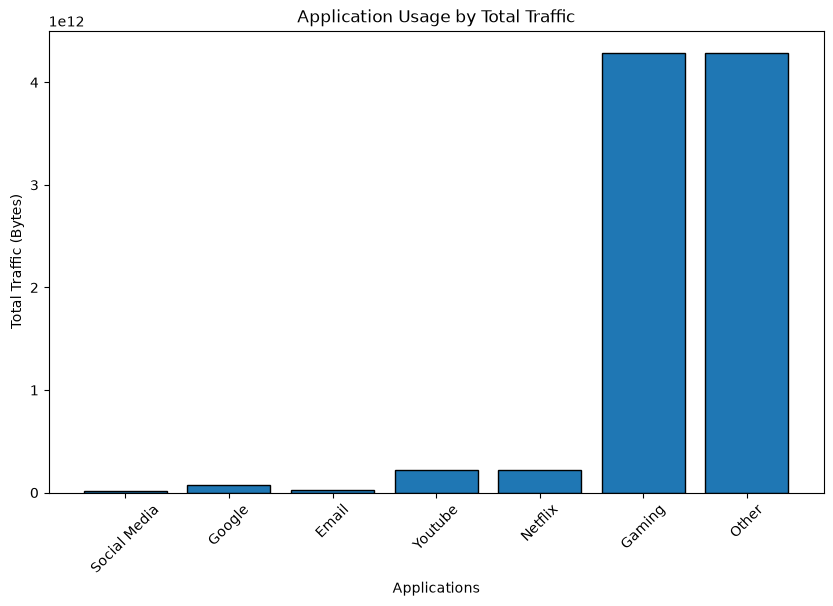

In [23]:
applications = {
    'Social Media': telecom_clean['Social Media DL (Bytes)'].sum() + telecom_clean['Social Media UL (Bytes)'].sum(),
    'Google': telecom_clean['Google DL (Bytes)'].sum() + telecom_clean['Google UL (Bytes)'].sum(),
    'Email': telecom_clean['Email DL (Bytes)'].sum() + telecom_clean['Email UL (Bytes)'].sum(),
    'Youtube': telecom_clean['Youtube DL (Bytes)'].sum() + telecom_clean['Youtube UL (Bytes)'].sum(),
    'Netflix': telecom_clean['Netflix DL (Bytes)'].sum() + telecom_clean['Netflix UL (Bytes)'].sum(),
    'Gaming': telecom_clean['Gaming DL (Bytes)'].sum() + telecom_clean['Gaming UL (Bytes)'].sum(),
    'Other': telecom_clean['Other DL (Bytes)'].sum() + telecom_clean['Other UL (Bytes)'].sum()
}

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    applications.keys(),
    applications.values(),
    edgecolor='black'
)

plt.title("Application Usage by Total Traffic")
plt.xlabel("Applications")
plt.ylabel("Total Traffic (Bytes)")
plt.xticks(rotation=45)

plt.show()

### Interpretation:
The chart shows the total network traffic generated by different applications. Gaming and Other applications generate the highest total traffic, followed by YouTube and Netflix. Google, Social Media, and Email contribute comparatively less network traffic. This indicates that a large proportion of the telecom network traffic is generated by Gaming and Other services.




Business Insight:

The telecom company should closely monitor network demand from Gaming and Other services, as they account for the largest share of total traffic. Understanding application usage patterns can help optimize bandwidth allocation, improve network performance, and enhance customer experience.



Business Recommendation:

Monitor traffic trends for high-usage applications such as Gaming and Other services. The telecom company can optimize network capacity and infrastructure based on application demand to reduce potential congestion and maintain service quality.

In [55]:
# Application traffic per customer

application_columns = {
    'Social Media': [
        'Social Media DL (Bytes)',
        'Social Media UL (Bytes)'
    ],
    'Google': [
        'Google DL (Bytes)',
        'Google UL (Bytes)'
    ],
    'Email': [
        'Email DL (Bytes)',
        'Email UL (Bytes)'
    ],
    'Youtube': [
        'Youtube DL (Bytes)',
        'Youtube UL (Bytes)'
    ],
    'Netflix': [
        'Netflix DL (Bytes)',
        'Netflix UL (Bytes)'
    ],
    'Gaming': [
        'Gaming DL (Bytes)',
        'Gaming UL (Bytes)'
    ],
    'Other': [
        'Other DL (Bytes)',
        'Other UL (Bytes)'
    ]
}

# Create customer-level application traffic
application_user_traffic = telecom_clean[['MSISDN/Number']].copy()

for app, columns in application_columns.items():
    application_user_traffic[app] = (
        telecom_clean[columns[0]] +
        telecom_clean[columns[1]]
    )

# Aggregate application traffic per customer
application_user_traffic = (
    application_user_traffic
    .groupby('MSISDN/Number')
    .sum()
    .reset_index()
)

application_user_traffic.head()

,MSISDN/Number,Social Media,Google,Email,Youtube,Netflix,Gaming,Other
0,3.360107e+10,3327033,6713895,2271820,21002980,15847618,311150719,82938064
1,3.360115e+10,515150,5937859,1320377,31924425,10013669,17530872,25944298
2,3.360118e+10,3647677,7784081,6588661,16376702,53807327,1092436967,400188309
3,3.360119e+10,3253219,5893919,3163932,30342376,19361927,546425407,18695590
4,3.360121e+10,1448152,11173621,628806,28616098,9953253,206396185,108075525


In [56]:
# Total traffic by application
application_totals = application_user_traffic.drop(
    columns=['MSISDN/Number']
).sum().sort_values(ascending=False)

print("Total Traffic by Application:")
print(application_totals)

Total Traffic by Application:
Other           4289816306829
Gaming          4284497486816
Youtube          225048951262
Netflix          224615274213
Google            78526995910
Email             22614973408
Social Media      18398913372
dtype: int64


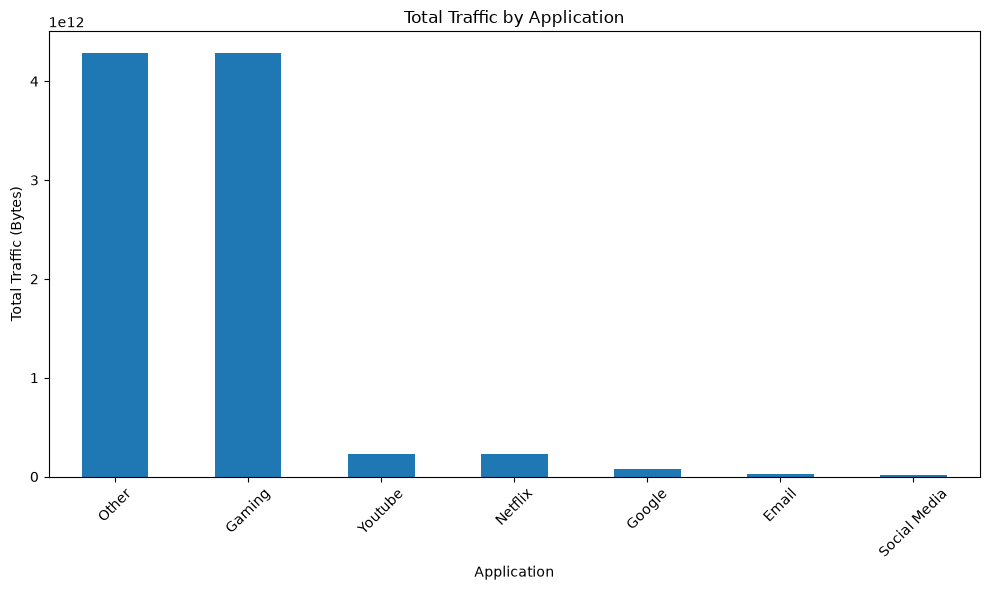

In [57]:
# Visualize total traffic by application

plt.figure(figsize=(10, 6))

application_totals.plot(kind='bar')

plt.title("Total Traffic by Application")
plt.xlabel("Application")
plt.ylabel("Total Traffic (Bytes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Interpretation:

Other and Gaming applications generate the highest total network traffic, followed by YouTube and Netflix. Google, Email, and Social Media generate considerably lower traffic.

This indicates that Gaming and Other services are the major contributors to overall network demand and may require greater bandwidth and capacity planning.

### Business Insight:

The telecom company should closely monitor traffic from Gaming and Other applications because they account for the largest share of network usage. Understanding these application usage patterns can help optimize bandwidth allocation and maintain network performance.

### Business Recommendation:

The company should monitor traffic trends for high-usage applications such as Gaming and Other services and plan network capacity according to demand. This can help reduce congestion and maintain a good customer experience.

## 6. Customer Engagement Analysis

In [59]:
# Top 10 customers by session frequency

top10_frequency = customer_engagement.nlargest(
    10, 'session_frequency'
)[[
    'MSISDN/Number',
    'session_frequency'
]]

top10_frequency

,MSISDN/Number,session_frequency
5995,3.367591e+10,86
5648,3.366913e+10,6
5657,3.366917e+10,6
6892,3.369966e+10,6
1896,3.365287e+10,5
2338,3.365895e+10,5
7778,3.376353e+10,5
427,3.361644e+10,4
1549,3.365033e+10,4
2468,3.365922e+10,4


In [60]:
# Top 10 customers by total session duration

top10_duration = customer_engagement.nlargest(
    10, 'total_duration'
)[[
    'MSISDN/Number',
    'total_duration'
]]

top10_duration

,MSISDN/Number,total_duration
5995,3.367591e+10,4223275
2468,3.365922e+10,3146359
4419,3.366496e+10,1823652
5648,3.366913e+10,1532447
7778,3.376353e+10,1507998
6192,3.368185e+10,1365104
7218,3.376063e+10,1361762
2237,3.365875e+10,1326897
6981,3.375034e+10,1321509
6945,3.369980e+10,1089009


In [61]:
# Top 10 customers by total traffic

top10_traffic = customer_engagement.nlargest(
    10, 'total_traffic'
)[[
    'MSISDN/Number',
    'total_traffic'
]]

top10_traffic

,MSISDN/Number,total_traffic
5995,3.367591e+10,40611050061
6892,3.369966e+10,2858293624
5648,3.366913e+10,2718540665
1896,3.365287e+10,2685141548
8004,3.376954e+10,2473005804
2338,3.365895e+10,2439683120
1549,3.365033e+10,2312218502
3241,3.366132e+10,2288184480
8321,3.378797e+10,2277219602
7520,3.376197e+10,2235990659


In [62]:
# Top 10 most engaged customers per application

top10_app_users = (
    telecom_clean.groupby('MSISDN/Number')
    .agg(
        youtube=('Youtube DL (Bytes)', 'sum'),
        netflix=('Netflix DL (Bytes)', 'sum'),
        gaming=('Gaming DL (Bytes)', 'sum'),
        google=('Google DL (Bytes)', 'sum'),
        email=('Email DL (Bytes)', 'sum'),
        social_media=('Social Media DL (Bytes)', 'sum'),
        other=('Other DL (Bytes)', 'sum')
    )
    .reset_index()
)

top10_app_users.head()

,MSISDN/Number,youtube,netflix,gaming,google,email,social_media,other
0,3.360107e+10,11451519,2639976,301494163,6166864,1632391,3325577,69545843
1,3.360115e+10,12593552,414503,4623308,2843124,940086,502573,11119211
2,3.360118e+10,3246395,27600223,1077470837,5503853,5722802,3537144,383246344
3,3.360119e+10,16441113,16890784,529950100,2307406,2231245,3192389,11724658
4,3.360121e+10,9202907,6104376,193864648,10843760,122288,1408576,105631325


In [63]:
# Top 10 customers for each application

applications = [
    'youtube',
    'netflix',
    'gaming',
    'google',
    'email',
    'social_media',
    'other'
]

for app in applications:
    print(f"\nTop 10 customers for {app.title()}:")
    display(
        top10_app_users.nlargest(
            10, app
        )[['MSISDN/Number', app]]
    )


Top 10 customers for Youtube:


,MSISDN/Number,youtube
5995,3.367591e+10,1005323375
6892,3.369966e+10,73887569
7778,3.376353e+10,71237086
2468,3.365922e+10,67612919
3740,3.366276e+10,61300506
5451,3.366846e+10,58996674
62,3.360366e+10,58508601
6254,3.368390e+10,57469219
5657,3.366917e+10,55157624
6741,3.369906e+10,53786963



Top 10 customers for Netflix:


,MSISDN/Number,netflix
5995,3.367591e+10,882935883
5657,3.366917e+10,80082886
5648,3.366913e+10,75672335
6830,3.369943e+10,74826985
6892,3.369966e+10,74728308
607,3.362125e+10,64465607
848,3.362730e+10,63183128
2468,3.365922e+10,63034986
8004,3.376954e+10,60072268
7778,3.376353e+10,58801920



Top 10 customers for Gaming:


...

,MSISDN/Number,email
5995,3.367591e+10,142255579
5648,3.366913e+10,12265255
63,3.360369e+10,9958408
1896,3.365287e+10,9397918
780,3.362559e+10,9330968
5657,3.366917e+10,9262096
7520,3.376197e+10,9013643
5451,3.366846e+10,8839940
1549,3.365033e+10,8464434
2338,3.365895e+10,8287100



Top 10 customers for Social_Media:


,MSISDN/Number,social_media
5995,3.367591e+10,156666259
5648,3.366913e+10,15122679
5657,3.366917e+10,12856803
6892,3.369966e+10,12448736
1896,3.365287e+10,10821761
3740,3.366276e+10,9931105
7778,3.376353e+10,9889718
4611,3.366546e+10,9879224
2338,3.365895e+10,9540597
844,3.362708e+10,8259391



Top 10 customers for Other:


,MSISDN/Number,other
5995,3.367591e+10,34312881396
5657,3.366917e+10,3528305389
6892,3.369966e+10,3449369324
2338,3.365895e+10,3375294606
427,3.361644e+10,2641067410
5648,3.366913e+10,2366020282
1896,3.365287e+10,2154891062
1315,3.364618e+10,2014606182
2725,3.365979e+10,2012238394
1167,3.363803e+10,2002988959


In [64]:
# Top 3 applications by total traffic

application_totals = {
    'YouTube': telecom_clean['Youtube DL (Bytes)'].sum(),
    'Netflix': telecom_clean['Netflix DL (Bytes)'].sum(),
    'Gaming': telecom_clean['Gaming DL (Bytes)'].sum(),
    'Google': telecom_clean['Google DL (Bytes)'].sum(),
    'Email': telecom_clean['Email DL (Bytes)'].sum(),
    'Social Media': telecom_clean['Social Media DL (Bytes)'].sum(),
    'Other': telecom_clean['Other DL (Bytes)'].sum()
}

application_totals_df = pd.DataFrame(
    list(application_totals.items()),
    columns=['Application', 'Total Traffic']
)

top3_applications = application_totals_df.nlargest(
    3, 'Total Traffic'
)

top3_applications

,Application,Total Traffic
6,Other,4206465563593
2,Gaming,4201975845819
1,Netflix,115949106930


In [24]:
customer_engagement = telecom_clean.groupby('MSISDN/Number').agg(
    session_frequency=('MSISDN/Number', 'count'),
    total_duration=('Dur. (ms)', 'sum'),
    total_dl=('Total DL (Bytes)', 'sum'),
    total_ul=('Total UL (Bytes)', 'sum')
).reset_index()

customer_engagement['total_traffic'] = (
    customer_engagement['total_dl'] +
    customer_engagement['total_ul']
)

customer_engagement.head()

,MSISDN/Number,session_frequency,total_duration,total_dl,total_ul,total_traffic
0,3.360107e+10,1,32737,326710490,46995796,373706286
1,3.360115e+10,1,86400,21917146,60150293,82067439
2,3.360118e+10,2,100737,1123081254,74502126,1197583380
3,3.360119e+10,1,55742,571013037,44398675,615411712
4,3.360121e+10,1,31016,221546555,39113760,260660315


In [66]:
# Create 10 decile groups based on total session duration

customer_engagement['duration_decile'] = pd.qcut(
    customer_engagement['total_duration'].rank(method='first'),
    q=10,
    labels=False
) + 1

# Calculate total duration, total traffic and number of customers per decile

decile_analysis = customer_engagement.groupby(
    'duration_decile'
).agg(
    total_duration=('total_duration', 'sum'),
    total_traffic=('total_traffic', 'sum'),
    customers=('MSISDN/Number', 'count')
).reset_index()

decile_analysis

,duration_decile,total_duration,total_traffic,customers
0,1,25655717,423101670520,835
1,2,32626552,412696341167,834
2,3,39994206,412451619088,834
3,4,48463775,492145483939,834
4,5,63339254,576554708384,834
5,6,72050235,406309359132,834
6,7,72056766,406225835510,834
7,8,72057137,406343454612,834
8,9,77637111,594870295275,834
9,10,174519729,806354570590,834


### Decile Analysis Interpretation

Customers in higher duration deciles generate substantially higher total session duration and network traffic. The highest-duration customer group (Decile 10) contributes the largest overall usage, indicating that a relatively high-engagement segment accounts for a significant share of network demand.

**Business Insight:**

The telecom company should identify and retain high-engagement customers while monitoring their network usage. Lower-duration customer groups may be targeted with engagement strategies to increase usage and customer value.

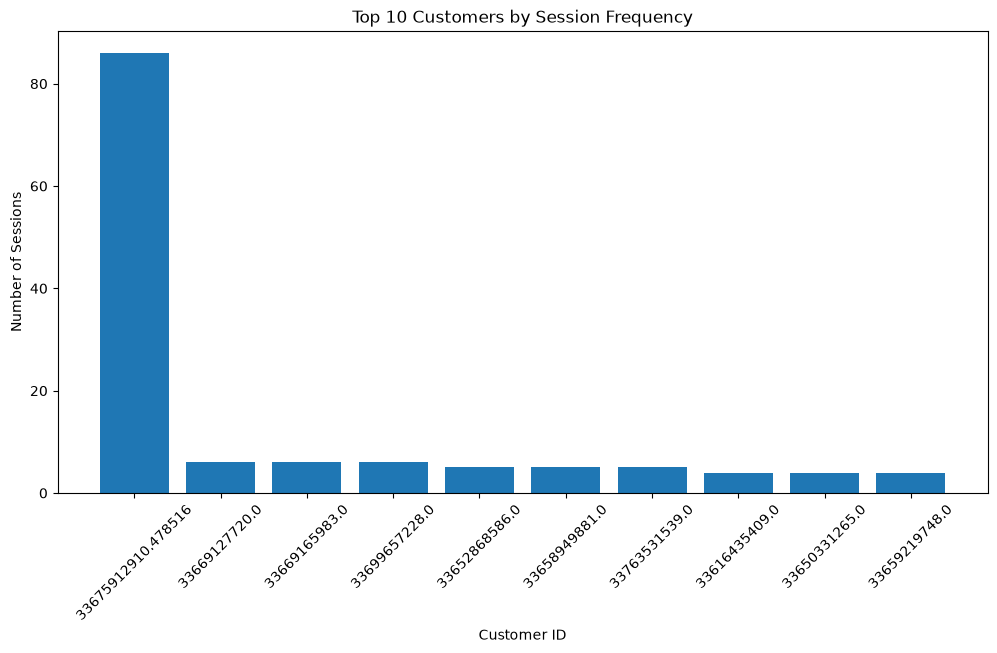

In [25]:
top10_frequency = customer_engagement.nlargest(
    10, 'session_frequency'
)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_frequency['MSISDN/Number'].astype(str),
    top10_frequency['session_frequency']
)

plt.title("Top 10 Customers by Session Frequency")
plt.xlabel("Customer ID")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)

plt.show()

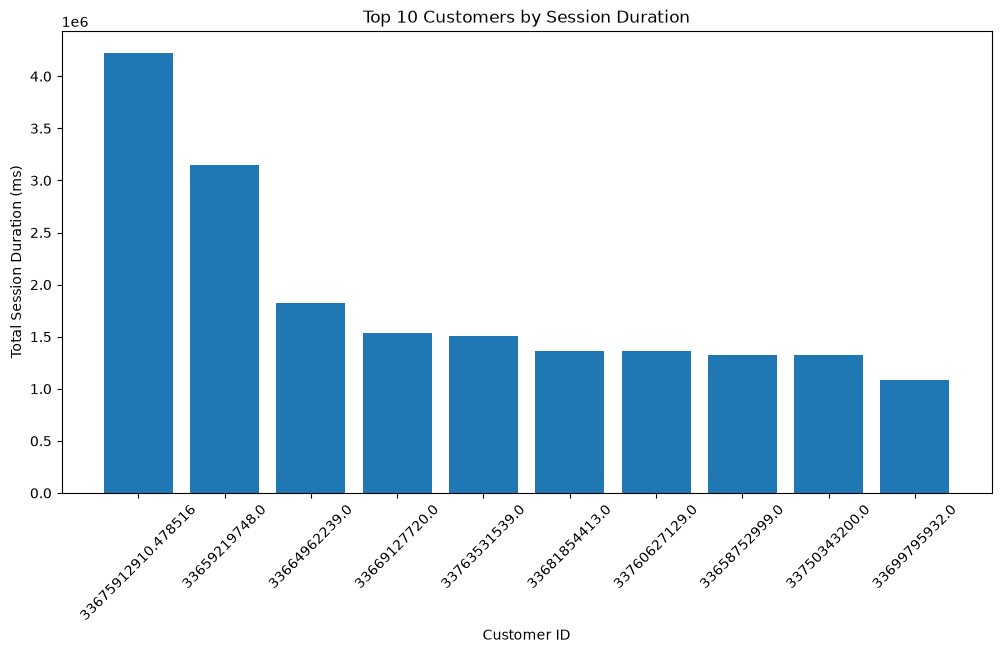

In [26]:
top10_duration = customer_engagement.nlargest(
    10, 'total_duration'
)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_duration['MSISDN/Number'].astype(str),
    top10_duration['total_duration']
)

plt.title("Top 10 Customers by Session Duration")
plt.xlabel("Customer ID")
plt.ylabel("Total Session Duration (ms)")
plt.xticks(rotation=45)

plt.show()

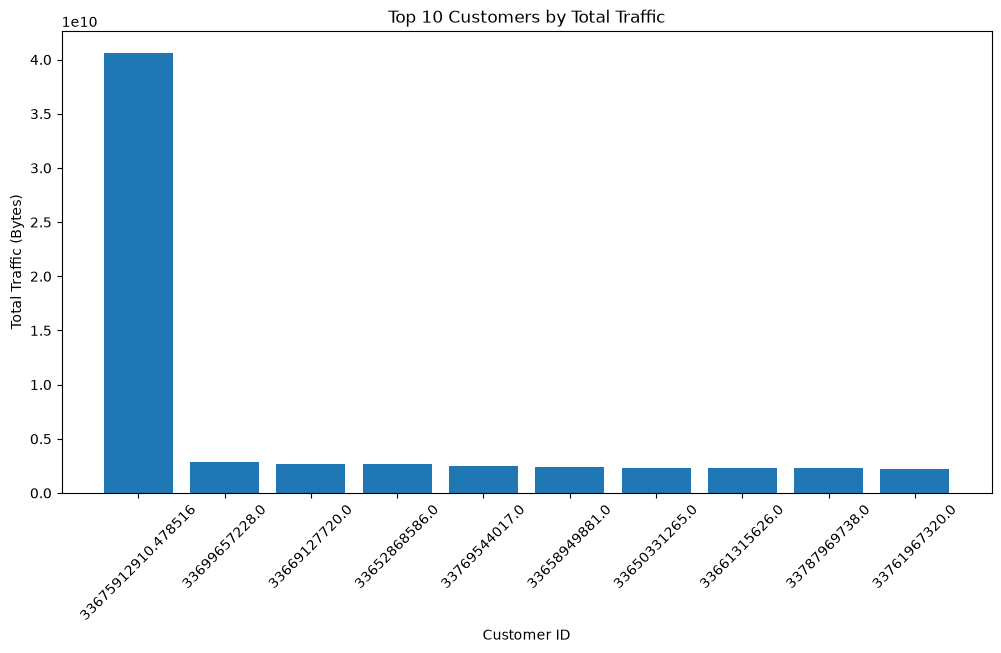

In [28]:
top10_traffic = customer_engagement.nlargest(
    10, 'total_traffic'
)

plt.figure(figsize=(12, 6))

plt.bar(
    top10_traffic['MSISDN/Number'].astype(str),
    top10_traffic['total_traffic']
)

plt.title("Top 10 Customers by Total Traffic")
plt.xlabel("Customer ID")
plt.ylabel("Total Traffic (Bytes)")
plt.xticks(rotation=45)

plt.show()



In [29]:
engagement_metrics = customer_engagement[
    ['session_frequency', 'total_duration', 'total_traffic']
]

engagement_metrics.head()

,session_frequency,total_duration,total_traffic
0,1,32737,373706286
1,1,86400,82067439
2,2,100737,1197583380
3,1,55742,615411712
4,1,31016,260660315


Customer Segmentation using K-Means

In [58]:
from sklearn.preprocessing import StandardScaler

# Log transform to reduce the effect of extreme values
engagement_features_log = np.log1p(engagement_metrics)

# Standardize the transformed features
scaler = StandardScaler()

engagement_normalized = scaler.fit_transform(engagement_features_log)

engagement_normalized[:5]

array([[-0.44729098, -1.49635542, -0.37089183],
       [-0.44729098,  0.44304055, -2.58067059],
       [ 1.95103354,  0.74984626,  1.32673934],
       [-0.44729098, -0.43276353,  0.3562431 ],
       [-0.44729098, -1.60427239, -0.8960335 ]])

In [31]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(engagement_normalized)
    inertia.append(kmeans.inertia_)

inertia

[10946.538097526496,
 7155.2692674807,
 4485.596939052093,
 3511.7217675951956,
 2701.4503334367973,
 2339.260626606886,
 2028.1273880487418]

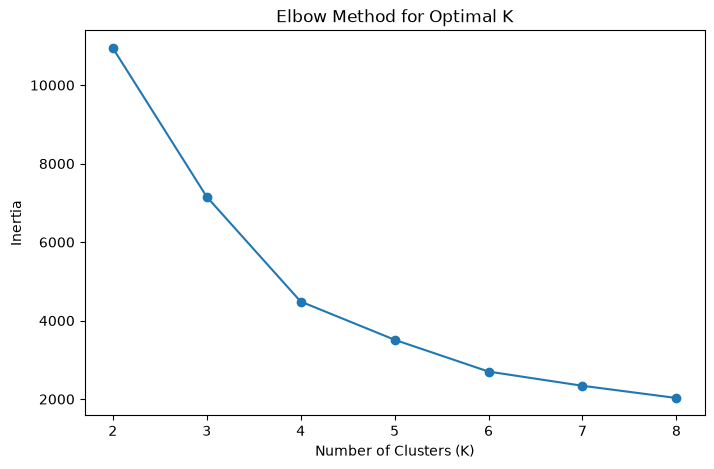

In [96]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 9), inertia, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_labels = kmeans.fit_predict(engagement_normalized)

customer_engagement['cluster'] = customer_labels

customer_engagement.head()

,MSISDN/Number,session_frequency,total_duration,total_dl,total_ul,total_traffic,cluster
0,3.360107e+10,1,32737,326710490,46995796,373706286,0
1,3.360115e+10,1,86400,21917146,60150293,82067439,0
2,3.360118e+10,2,100737,1123081254,74502126,1197583380,0
3,3.360119e+10,1,55742,571013037,44398675,615411712,0
4,3.360121e+10,1,31016,221546555,39113760,260660315,0


In [47]:
cluster_summary = customer_engagement.groupby('cluster').agg(
    customers=('MSISDN/Number', 'count'),

    min_session_frequency=('session_frequency', 'min'),
    max_session_frequency=('session_frequency', 'max'),
    avg_session_frequency=('session_frequency', 'mean'),
    total_session_frequency=('session_frequency', 'sum'),

    min_duration=('total_duration', 'min'),
    max_duration=('total_duration', 'max'),
    avg_duration=('total_duration', 'mean'),
    total_duration=('total_duration', 'sum'),

    min_traffic=('total_traffic', 'min'),
    max_traffic=('total_traffic', 'max'),
    avg_traffic=('total_traffic', 'mean'),
    total_traffic=('total_traffic', 'sum')
).reset_index()

cluster_summary

,cluster,customers,min_session_frequency,max_session_frequency,avg_session_frequency,total_session_frequency,min_duration,max_duration,avg_duration,total_duration,min_traffic,max_traffic,avg_traffic,total_traffic
0,0,8279,1,4,1.183355,9797,22958,447459,7.547731e+04,624876646,28956107,2473005804,5.845589e+08,4839563485599
1,1,1,86,86,86.000000,86,4223275,4223275,4.223275e+06,4223275,40611050061,40611050061,4.061105e+10,40611050061
2,2,61,1,6,1.918033,117,404238,3146359,8.082059e+05,49300561,101047021,2858293624,9.324394e+08,56878802557


### Cluster Interpretation

**Cluster 0 – Low Engagement:**  
This is the largest customer segment, with 8,279 customers. These customers have relatively low session frequency, session duration, and total traffic.

**Cluster 1 – Extremely High Engagement:**  
This cluster contains only 1 customer. This customer has exceptionally high session frequency, session duration, and total traffic, representing an extreme high-engagement user.

**Cluster 2 – Moderate/High Engagement:**  
This cluster contains 61 customers. These customers show higher average session frequency, session duration, and traffic than Cluster 0, indicating relatively higher engagement.

### Business Insight

Most customers belong to the low-engagement segment. The telecom company should focus on increasing engagement among this large customer group while monitoring high-usage customers to ensure sufficient network capacity.




In [48]:
# Check customers with unusually high session frequency

customer_engagement[
    customer_engagement['session_frequency'] > 10
][[
    'MSISDN/Number',
    'session_frequency',
    'total_duration',
    'total_traffic'
]]

,MSISDN/Number,session_frequency,total_duration,total_traffic
5995,3.367591e+10,86,4223275,40611050061


In [49]:
customer_engagement['session_frequency'].describe()

count    8341.000000
mean        1.198897
std         1.021063
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        86.000000
Name: session_frequency, dtype: float64

In [53]:
# Create engagement features
engagement_features = customer_engagement[
    ['session_frequency', 'total_duration', 'total_traffic']
].copy()

# Reduce the effect of extreme values using log transformation
engagement_features_log = np.log1p(engagement_features)

# Display the transformed data
engagement_features_log.head()

,session_frequency,total_duration,total_traffic
0,0.693147,10.396292,19.738981
1,0.693147,11.366755,18.223052
2,1.098612,11.520278,20.903572
3,0.693147,10.928507,20.237802
4,0.693147,10.342291,19.378729


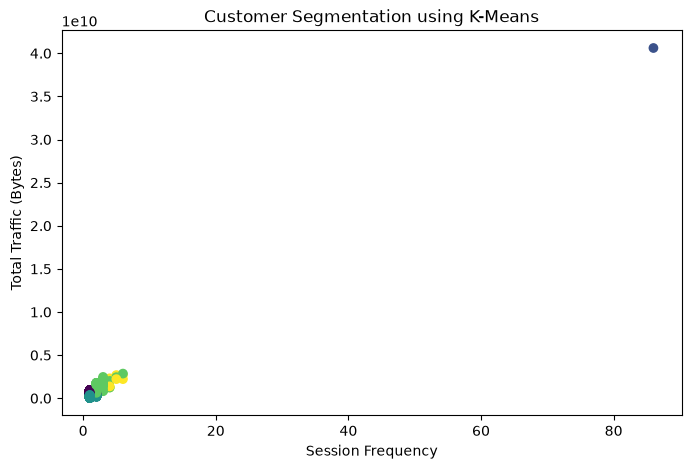

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    customer_engagement['session_frequency'],
    customer_engagement['total_traffic'],
    c=customer_engagement['cluster']
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Session Frequency")
plt.ylabel("Total Traffic (Bytes)")

plt.show()

# 7. User Experience Analysis

In [37]:
[c for c in telecom_clean.columns if 'TCP' in c or 'RTT' in c or 'Throughput' in c or 'TP' in c]

['Avg RTT DL (ms)',
 'Avg RTT UL (ms)',
 'Avg Bearer TP DL (kbps)',
 'Avg Bearer TP UL (kbps)',
 'TCP DL Retrans. Vol (Bytes)',
 'TCP UL Retrans. Vol (Bytes)',
 'DL TP < 50 Kbps (%)',
 '50 Kbps < DL TP < 250 Kbps (%)',
 '250 Kbps < DL TP < 1 Mbps (%)',
 'DL TP > 1 Mbps (%)',
 'UL TP < 10 Kbps (%)',
 '10 Kbps < UL TP < 50 Kbps (%)',
 '50 Kbps < UL TP < 300 Kbps (%)',
 'UL TP > 300 Kbps (%)',
 'HTTP DL (Bytes)',
 'HTTP UL (Bytes)']

In [ ]:
# User Experience Analysis 

experience_data = telecom_clean.copy()

# Columns required for experience analysis
experience_cols = [
    'TCP DL Retrans. Vol (Bytes)',
    'TCP UL Retrans. Vol (Bytes)',
    'Avg RTT DL (ms)',
    'Avg RTT UL (ms)',
    'Avg Bearer TP DL (kbps)',
    'Avg Bearer TP UL (kbps)'
]

# Convert numeric columns to float
# This allows us to replace outliers with mean values
for col in experience_cols:
    experience_data[col] = pd.to_numeric(
        experience_data[col],
        errors='coerce'
    ).astype(float)

# Handle missing values using the mean
for col in experience_cols:
    experience_data[col] = experience_data[col].fillna(
        experience_data[col].mean()
    )

# Handle outliers using the mean
for col in experience_cols:

    Q1 = experience_data[col].quantile(0.25)
    Q3 = experience_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mean_value = experience_data[col].mean()

    outliers = (
        (experience_data[col] < lower_bound) |
        (experience_data[col] > upper_bound)
    )

    experience_data.loc[outliers, col] = mean_value


# Create average TCP retransmission
experience_data['avg_tcp_retransmission'] = experience_data[
    ['TCP DL Retrans. Vol (Bytes)',
     'TCP UL Retrans. Vol (Bytes)']
].mean(axis=1)


# Create average RTT
experience_data['avg_rtt'] = experience_data[
    ['Avg RTT DL (ms)',
     'Avg RTT UL (ms)']
].mean(axis=1)


# Create average throughput
experience_data['avg_throughput'] = experience_data[
    ['Avg Bearer TP DL (kbps)',
     'Avg Bearer TP UL (kbps)']
].mean(axis=1)


# Aggregate experience metrics per customer
user_experience = experience_data.groupby('MSISDN/Number').agg(
    avg_tcp_retransmission=('avg_tcp_retransmission', 'mean'),
    avg_rtt=('avg_rtt', 'mean'),
    handset_type=(
        'Handset Type',
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'
    ),
    avg_throughput=('avg_throughput', 'mean')
).reset_index()


# Display result
user_experience.head()

,MSISDN/Number,avg_tcp_retransmission,avg_rtt,handset_type,avg_throughput
0,3.360107e+10,1.447950e+04,16.000000,Samsung Galaxy S9 Plus (Sm-G965F),1451.5000
1,3.360115e+10,1.569616e+06,47.500000,Samsung Galaxy A5 Sm-A520F,23889.8001
2,3.360118e+10,5.641499e+06,49.749635,undefined,3595.0000
3,3.360119e+10,2.979565e+05,63.000000,Samsung Galaxy S9,17192.5000
4,3.360121e+10,1.085915e+07,30.000000,Apple iPhone Xs (A2097),31.5000


In [40]:
# Top 10, Bottom 10 and Most Frequent Values

# 1. TCP Retransmission
tcp_values = experience_data['avg_tcp_retransmission']

print("TOP 10 TCP Retransmission Values:")
print(tcp_values.nlargest(10))

print("\nBOTTOM 10 TCP Retransmission Values:")
print(tcp_values.nsmallest(10))

print("\nMOST FREQUENT TCP Retransmission Values:")
print(tcp_values.value_counts().head(10))


# 2. RTT
rtt_values = experience_data['avg_rtt']

print("\nTOP 10 RTT Values:")
print(rtt_values.nlargest(10))

print("\nBOTTOM 10 RTT Values:")
print(rtt_values.nsmallest(10))

print("\nMOST FREQUENT RTT Values:")
print(rtt_values.value_counts().head(10))


# 3. Throughput
throughput_values = experience_data['avg_throughput']

print("\nTOP 10 Throughput Values:")
print(throughput_values.nlargest(10))

print("\nBOTTOM 10 Throughput Values:")
print(throughput_values.nsmallest(10))

print("\nMOST FREQUENT Throughput Values:")
print(throughput_values.value_counts().head(10))

TOP 10 TCP Retransmission Values:
1126    2.628004e+07
1873    2.597423e+07
3661    2.584261e+07
2244    2.572923e+07
2619    2.566646e+07
1180    2.536423e+07
6395    2.531463e+07
5818    2.530655e+07
2652    2.523972e+07
3857    2.520232e+07
Name: avg_tcp_retransmission, dtype: float64

BOTTOM 10 TCP Retransmission Values:
8794     64.0
8318     89.5
5385    144.5
5875    152.5
8346    185.5
4762    200.5
7381    207.5
8829    208.0
7723    226.5
8800    289.0
Name: avg_tcp_retransmission, dtype: float64

MOST FREQUENT TCP Retransmission Values:
avg_tcp_retransmission
1.085915e+07    3340
1.043636e+07      28
4.241005e+05      26
1.043637e+07      17
4.234545e+05      11
4.247655e+05      10
4.240795e+05      10
1.043638e+07      10
4.234815e+05      10
4.234735e+05       9
Name: count, dtype: int64

TOP 10 RTT Values:
1494    122.0
2232    120.5
2953    119.0
275     118.5
146     117.5
2126    117.0
2171    117.0
2601    117.0
2803    115.5
3200    114.5
Name: avg_rtt, dtype: float

Average Throughput by Handset Type:
handset_type
Samsung Galaxy Note 2 (Gt-N7105)         38713.5
Lg G3                                    38056.0
Huawei Mrd-Lx1                           36874.5
New-Bund Technol. Thor                   36470.5
Oppo Cph1723                             35334.0
Samsung Galaxy A5 Sm-A520F Ds            35027.5
Asustek Asus Zenfone2 Ze551Ml            34071.5
Asustek Asus Zenfone 3 Deluxe Zs570Kl    33988.5
Huawei Aum-Al00                          33912.0
Huawei Honor 7A                          32950.5
Name: avg_throughput, dtype: float64


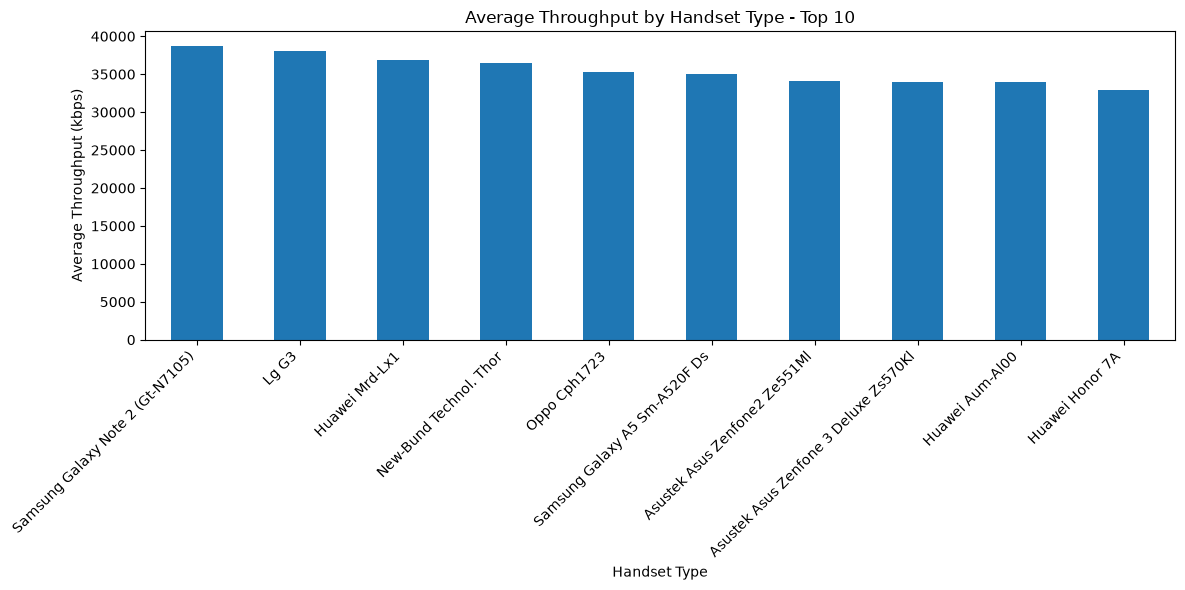

In [41]:
# Average Throughput per Handset Type

throughput_by_handset = (
    user_experience
    .groupby('handset_type')['avg_throughput']
    .mean()
    .sort_values(ascending=False)
)

# Display the results
print("Average Throughput by Handset Type:")
print(throughput_by_handset.head(10))

# Plot top 10 handset types
plt.figure(figsize=(12, 6))

throughput_by_handset.head(10).plot(kind='bar')

plt.title("Average Throughput by Handset Type - Top 10")
plt.xlabel("Handset Type")
plt.ylabel("Average Throughput (kbps)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Interpretation:
The average throughput varies across handset types. Samsung Galaxy Note 2 (GT-N7105) has the highest average throughput among the top 10 handset types, followed by LG G3 and Huawei Mrd-Lx1. This indicates that network performance can vary depending on the handset device.

Average TCP Retransmission by Handset Type:
Handset Type
Samsung Galaxy J3 (Sm-J330G Ds)                 1.734815e+07
Tcl Communicatio. Pixi 4 6 3G Android           1.587218e+07
Sony Mobile Comm. Xperia Xz2                    1.247441e+07
Neel Enterprise Kolor Crosscalltrekker-X2       1.122107e+07
D-Link Corporati. D-Link Dwr-921                1.104178e+07
Samsung Galaxy S (Gt-I9000)                     1.085915e+07
Samsung Galaxy Y (Gt-S5360)                     1.085915e+07
Acer Liquid Zest Plus                           1.085915e+07
Tcl Communicatio. Alcatel Onetouch Pop 3 (5)    1.085915e+07
Wct Uno                                         1.085915e+07
Name: avg_tcp_retransmission, dtype: float64


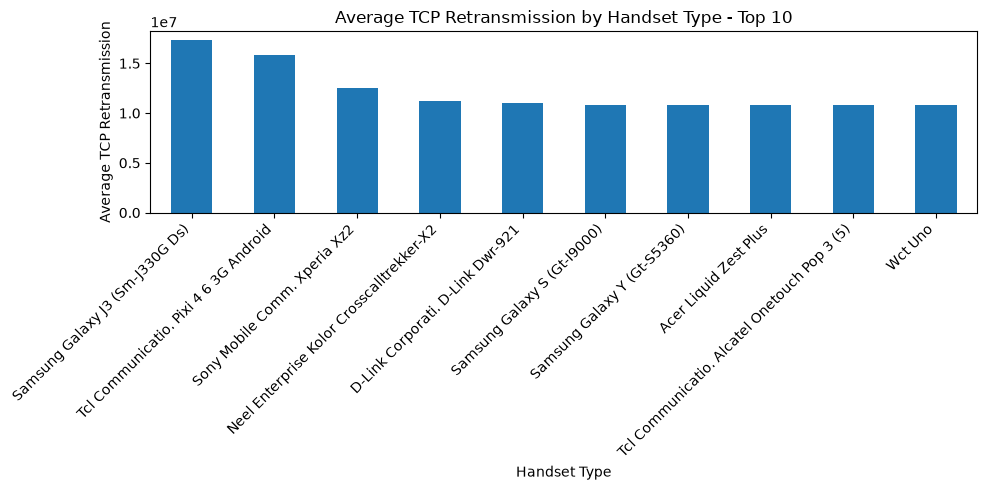

In [42]:
# Average TCP Retransmission by Handset Type

tcp_by_handset = (
    experience_data.groupby('Handset Type')['avg_tcp_retransmission']
    .mean()
    .sort_values(ascending=False)
)

print("Average TCP Retransmission by Handset Type:")
print(tcp_by_handset.head(10))

plt.figure(figsize=(10, 5))

tcp_by_handset.head(10).plot(kind='bar')

plt.title("Average TCP Retransmission by Handset Type - Top 10")
plt.xlabel("Handset Type")
plt.ylabel("Average TCP Retransmission")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation:

The average TCP retransmission varies across handset types. Higher TCP retransmission indicates that more data packets may need to be retransmitted, which can negatively affect network performance and user experience. The handset types with higher average TCP retransmission may require further investigation to understand whether device characteristics or network conditions are contributing to the issue.

### Customer Experience Segmentation using K-Means

K-Means clustering is used to segment customers into three groups based on their experience metrics: average TCP retransmission, average RTT, and average throughput.

In [43]:
# Customer Experience Segmentation using K-Means (k=3)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select experience metrics
experience_metrics = experience_data[
    ['avg_tcp_retransmission', 'avg_rtt', 'avg_throughput']
]

# Normalize the experience metrics
experience_scaler = StandardScaler()

experience_normalized = experience_scaler.fit_transform(
    experience_metrics
)

# Apply K-Means with 3 clusters
experience_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

experience_labels = experience_kmeans.fit_predict(
    experience_normalized
)

# Add cluster labels to the customer data
experience_data['experience_cluster'] = experience_labels

# Display the result
experience_data.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes),avg_tcp_retransmission,avg_rtt,avg_throughput,experience_cluster
0,13114483460844900352,2019-04-04 12:01:18,770,2019-04-25 14:35:31,662,1823652,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,...,278082303,14344150,171744450,8814393,36749741,308879636,1.085915e+07,23.50000,33.5,1
1,13114483482878900224,2019-04-09 13:04:04,235,2019-04-25 08:15:48,606,1365104,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,...,608750074,1170709,526904238,15055145,53800391,653384965,1.085915e+07,35.00000,21.0,1
2,13114483484080500736,2019-04-09 17:42:11,1,2019-04-25 11:58:13,652,1361762,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,...,229584621,395630,410692588,4215763,27883638,279807335,1.085915e+07,75.99927,7.5,2
3,13114483485442799616,2019-04-10 00:31:25,486,2019-04-25 07:36:35,171,1321509,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,...,799538153,10849722,749039933,12797283,43324218,846028530,1.085915e+07,75.99927,44.0,2
4,13114483499480700928,2019-04-12 20:10:23,565,2019-04-25 10:40:32,954,1089009,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,...,527707248,3529801,550709500,13910322,38542814,569138589,1.085915e+07,75.99927,7.5,2


In [45]:
# Summarize the three experience clusters

experience_cluster_summary = (
    experience_data
    .groupby('experience_cluster')
    .agg(
        customers=('MSISDN/Number', 'count'),
        avg_tcp_retransmission=('avg_tcp_retransmission', 'mean'),
        avg_rtt=('avg_rtt', 'mean'),
        avg_throughput=('avg_throughput', 'mean')
    )
    .reset_index()
)

experience_cluster_summary

,experience_cluster,customers,avg_tcp_retransmission,avg_rtt,avg_throughput
0,0,4551,1.150099e+06,33.514689,17304.918383
1,1,2855,1.111530e+07,23.939557,1625.679164
2,2,2594,6.407206e+06,75.092281,7530.330527


### Interpretation:

The K-Means segmentation divides customers into three experience groups.

- **Cluster 0** represents customers with the highest average throughput, indicating relatively strong network performance.
- **Cluster 1** has the lowest average RTT and TCP retransmission among the three clusters, indicating better latency and network reliability.
- **Cluster 2** shows substantially higher TCP retransmission and RTT along with the lowest throughput, indicating a comparatively poor user experience.

Cluster 2 should be prioritized for further investigation and network optimization.

# 8. Customer Satisfaction Analysis

In [67]:
customer_engagement.groupby('cluster')[
    ['session_frequency', 'total_duration', 'total_traffic']
].mean()

,session_frequency,total_duration,total_traffic
cluster,,,
0,1.183355,7.547731e+04,5.845589e+08
1,86.000000,4.223275e+06,4.061105e+10
2,1.918033,8.082059e+05,9.324394e+08


In [68]:
from scipy.spatial.distance import euclidean

# Identify the less-engaged cluster
less_engaged_cluster = 0

# Get the centroid of the less-engaged cluster
less_engaged_centroid = kmeans.cluster_centers_[less_engaged_cluster]

# Calculate engagement score for each customer
customer_engagement['engagement_score'] = [
    euclidean(row, less_engaged_centroid)
    for row in engagement_normalized
]

# Display the result
customer_engagement[
    ['MSISDN/Number', 'session_frequency', 'total_duration',
     'total_traffic', 'engagement_score']
].head()

,MSISDN/Number,session_frequency,total_duration,total_traffic,engagement_score
0,3.360107e+10,1,32737,373706286,1.539400
1,3.360115e+10,1,86400,82067439,2.652215
2,3.360118e+10,2,100737,1197583380,2.514369
3,3.360119e+10,1,55742,615411712,0.678300
4,3.360121e+10,1,31016,260660315,1.828175


In [70]:
# Find K-Means variables already created in the notebook

[name for name in globals() if 'kmeans' in name.lower()]

['KMeans', 'kmeans', 'experience_kmeans']

In [75]:
print("customer_engagement rows:", len(customer_engagement))
print("experience_data rows:", len(experience_data))

print(experience_data.columns)

customer_engagement rows: 8341
experience_data rows: 10000
Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer',
       'Handset Type', 'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL <

In [77]:
import numpy as np

# Worst experience cluster from your previous analysis
worst_experience_cluster = 2

# Centroid of the worst experience cluster
worst_experience_centroid = experience_kmeans.cluster_centers_[
    worst_experience_cluster
]

# Calculate experience score for the 10,000 experience records
experience_data['experience_score'] = np.linalg.norm(
    experience_normalized - worst_experience_centroid,
    axis=1
)

# Check result
experience_data[
    [
        'MSISDN/Number',
        'avg_tcp_retransmission',
        'avg_rtt',
        'avg_throughput',
        'experience_cluster',
        'experience_score'
    ]
].head()

,MSISDN/Number,avg_tcp_retransmission,avg_rtt,avg_throughput,experience_cluster,experience_score
0,3.366496e+10,1.085915e+07,23.50000,33.5,1,2.474389
1,3.368185e+10,1.085915e+07,35.00000,21.0,1,2.036542
2,3.376063e+10,1.085915e+07,75.99927,7.5,2,1.066225
3,3.375034e+10,1.085915e+07,75.99927,44.0,2,1.064302
4,3.369980e+10,1.085915e+07,75.99927,7.5,2,1.066225


In [78]:
# Keep only the columns needed from experience data
experience_scores = experience_data[
    ['MSISDN/Number', 'experience_score']
].copy()

# Merge engagement and experience scores using customer ID
satisfaction_data = customer_engagement.merge(
    experience_scores,
    on='MSISDN/Number',
    how='inner'
)

# Display result
satisfaction_data[
    ['MSISDN/Number', 'engagement_score', 'experience_score']
].head()

,MSISDN/Number,engagement_score,experience_score
0,3.360107e+10,1.539400,2.880351
1,3.360115e+10,2.652215,2.068339
2,3.360118e+10,2.514369,2.506544
3,3.360118e+10,2.514369,1.063907
4,3.360119e+10,0.678300,1.523424


In [79]:
# Calculate satisfaction score

satisfaction_data['satisfaction_score'] = (
    satisfaction_data['engagement_score'] +
    satisfaction_data['experience_score']
) / 2

# Display result
satisfaction_data[
    [
        'MSISDN/Number',
        'engagement_score',
        'experience_score',
        'satisfaction_score'
    ]
].head()

,MSISDN/Number,engagement_score,experience_score,satisfaction_score
0,3.360107e+10,1.539400,2.880351,2.209875
1,3.360115e+10,2.652215,2.068339,2.360277
2,3.360118e+10,2.514369,2.506544,2.510457
3,3.360118e+10,2.514369,1.063907,1.789138
4,3.360119e+10,0.678300,1.523424,1.100862


In [83]:
# Top 10 customers by satisfaction score

top10_satisfied = satisfaction_data.nlargest(
    10,
    'satisfaction_score'
)

top10_satisfied[
    [
        'MSISDN/Number',
        'engagement_score',
        'experience_score',
        'satisfaction_score'
    ]
]


,MSISDN/Number,engagement_score,experience_score,satisfaction_score
5995,3.367591e+10,24.277118,1.972353,13.124735
5648,3.366913e+10,9.706340,2.547425,6.126882
7778,3.376353e+10,8.972594,2.203365,5.587980
2468,3.365922e+10,9.407456,1.749380,5.578418
5657,3.366917e+10,8.933896,2.110903,5.522400
6892,3.369966e+10,8.269131,2.424991,5.347061
1896,3.365287e+10,7.894284,2.045103,4.969693
2338,3.365895e+10,7.553790,2.250795,4.902293
427,3.361644e+10,6.868051,2.565523,4.716787
4419,3.366496e+10,6.631117,2.474389,4.552753


In [81]:
# Create one experience score per customer
customer_experience_scores = (
    experience_data
    .groupby('MSISDN/Number', as_index=False)
    ['experience_score']
    .mean()
)

# Merge one experience score with each customer
satisfaction_data = customer_engagement.merge(
    customer_experience_scores,
    on='MSISDN/Number',
    how='inner'
)

# Calculate satisfaction score again
satisfaction_data['satisfaction_score'] = (
    satisfaction_data['engagement_score'] +
    satisfaction_data['experience_score']
) / 2

# Check number of rows and unique customers
print("Rows:", len(satisfaction_data))
print("Unique customers:", satisfaction_data['MSISDN/Number'].nunique())

Rows: 8341
Unique customers: 8341


In [85]:
# Prepare data for regression model

X = satisfaction_data[
    ['engagement_score', 'experience_score']
]

y = satisfaction_data['satisfaction_score']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8341, 2)
y shape: (8341,)


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6672, 2)
X_test shape: (1669, 2)
y_train shape: (6672,)
y_test shape: (1669,)


In [87]:
from sklearn.linear_model import LinearRegression

# Create the regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict satisfaction scores
y_pred = model.predict(X_test)

print("Model training completed.")
print("Number of predictions:", len(y_pred))

Model training completed.
Number of predictions: 1669


In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate the regression model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2.1542583973927917e-16
MSE: 1.0531524980974698e-31
RMSE: 3.2452311136457907e-16
R² Score: 1.0


In [89]:
from sklearn.cluster import KMeans

# Select engagement and experience scores
X_cluster = satisfaction_data[
    ['engagement_score', 'experience_score']
]

# Create K-Means model with 2 clusters
satisfaction_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Fit the model and assign clusters
satisfaction_data['satisfaction_cluster'] = (
    satisfaction_kmeans.fit_predict(X_cluster)
)

# Check number of customers in each cluster
print(
    satisfaction_data['satisfaction_cluster'].value_counts()
)

satisfaction_cluster
1    5668
0    2673
Name: count, dtype: int64


In [90]:
# Analyze average scores for each satisfaction cluster

cluster_summary = satisfaction_data.groupby(
    'satisfaction_cluster'
)[
    ['engagement_score', 'experience_score', 'satisfaction_score']
].mean()

print(cluster_summary)

                      engagement_score  experience_score  satisfaction_score
satisfaction_cluster                                                        
0                             2.491751          2.257505            2.374628
1                             1.032292          2.091177            1.561735


In [91]:
# Give meaningful names to the satisfaction clusters

satisfaction_data['satisfaction_group'] = (
    satisfaction_data['satisfaction_cluster'].map({
        0: 'More Satisfied',
        1: 'Less Satisfied'
    })
)

# Check the result
print(satisfaction_data['satisfaction_group'].value_counts())

satisfaction_group
Less Satisfied    5668
More Satisfied    2673
Name: count, dtype: int64


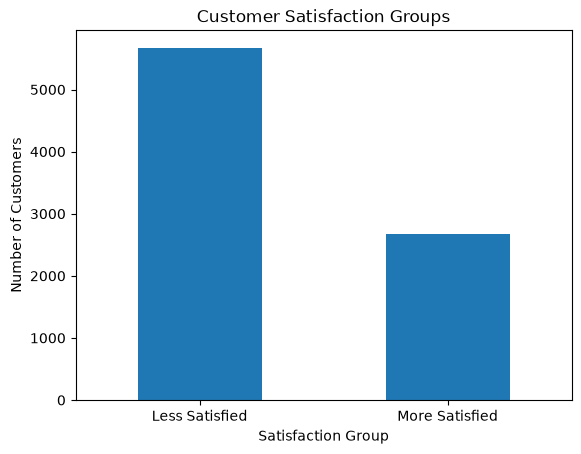

In [92]:
import matplotlib.pyplot as plt

# Count customers in each satisfaction group
satisfaction_counts = satisfaction_data['satisfaction_group'].value_counts()

# Create bar chart
satisfaction_counts.plot(kind='bar')

plt.title('Customer Satisfaction Groups')
plt.xlabel('Satisfaction Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

In [93]:
#  Average Satisfaction and Experience Score per Cluster

cluster_scores = satisfaction_data.groupby(
    'satisfaction_cluster'
)[['experience_score', 'satisfaction_score']].mean()

print(cluster_scores)

                      experience_score  satisfaction_score
satisfaction_cluster                                      
0                             2.257505            2.374628
1                             2.091177            1.561735


In [97]:
# Export final customer satisfaction scores

final_scores = satisfaction_data[
    [
        'MSISDN/Number',
        'engagement_score',
        'experience_score',
        'satisfaction_score'
    ]
].copy()

final_scores.to_csv(
    'telecom_satisfaction_scores.csv',
    index=False
)

print("File exported successfully")
print("Rows exported:", len(final_scores))

final_scores.head()

File exported successfully
Rows exported: 8341


,MSISDN/Number,engagement_score,experience_score,satisfaction_score
0,3.360107e+10,1.539400,2.880351,2.209875
1,3.360115e+10,2.652215,2.068339,2.360277
2,3.360118e+10,2.514369,1.785226,2.149797
3,3.360119e+10,0.678300,1.523424,1.100862
4,3.360121e+10,1.828175,2.223681,2.025928


### Model Tracking

This section records the satisfaction regression model version, execution time, parameters, evaluation metrics, and generated model artifact.

In [98]:
from datetime import datetime
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
X = satisfaction_data[['engagement_score', 'experience_score']]
y = satisfaction_data['satisfaction_score']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Track start time
start_time = datetime.now()

# Train model
tracked_model = LinearRegression()
tracked_model.fit(X_train, y_train)

# Prediction
y_pred = tracked_model.predict(X_test)

# Track end time
end_time = datetime.now()

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Save model artifact
joblib.dump(tracked_model, 'satisfaction_model_v1.pkl')

# Create tracking report
model_tracking = pd.DataFrame([{
    'model_version': 'v1.0',
    'model_name': 'Linear Regression',
    'start_time': start_time,
    'end_time': end_time,
    'source': 'TELECOM.ipynb - satisfaction_data',
    'parameters': str(tracked_model.get_params()),
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2_Score': r2,
    'artifact': 'satisfaction_model_v1.pkl'
}])

# Export tracking report
model_tracking.to_csv('model_tracking.csv', index=False)

model_tracking

,model_version,model_name,start_time,end_time,source,parameters,MAE,MSE,RMSE,R2_Score,artifact
0,v1.0,Linear Regression,2026-08-10 23:22:24.905018,2026-08-10 23:22:24.914732,TELECOM.ipynb - satisfaction_data,"{'copy_X': True, 'fit_intercept': True, 'n_job...",2.154258e-16,1.053152e-31,3.245231e-16,1.0,satisfaction_model_v1.pkl


# 9. Executive Summary
This Telecom Customer Analytics Project analyzed customer network usage, handset information, and application traffic using Python. The dataset was cleaned by handling missing values and preparing numerical and categorical variables for analysis.

Exploratory Data Analysis (EDA) was performed using summary statistics, histograms, boxplots, correlation analysis, scatter plots, and bar charts to understand customer usage patterns.

The analysis found that Apple, Huawei, and Samsung are the most widely used handset manufacturers, with Huawei B528S-23A being the most commonly used handset model. Gaming and Other applications generate the highest total network traffic, while Total Download and Total Upload do not show a clear strong linear relationship.

These findings can help the telecom company improve network planning, bandwidth allocation, customer support, and device-specific services.

# 10. Key Findings

• The dataset contained missing values that were successfully handled using mean and mode imputation.

• Most numerical variables showed skewed distributions with several outliers.

• The correlation heatmap indicated only a few strong relationships between network-related variables.

• There is no strong relationship between Total Download and Total Upload traffic.

• Apple, Huawei, and Samsung are the most widely used handset manufacturers.

• Huawei B528S-23A is the most commonly used handset model.

• Gaming and Other applications generate the highest amount of network traffic.

• These insights can help improve bandwidth allocation, customer service, and infrastructure planning.

# 11. Final Business Recommendations

• Increase network capacity for high-traffic applications such as Gaming and Other.

• Focus customer support and software optimization on the most commonly used handset manufacturers and models.

• Continuously monitor application traffic trends to improve Quality of Service (QoS).

• Optimize network resources during peak traffic hours to reduce congestion.

• Improve data collection processes to minimize missing or undefined handset information.

• Use customer usage patterns for future marketing campaigns and service planning.

# 9. Conclusion

The Telecom Customer Analytics Project successfully explored customer usage behavior, device popularity, and application traffic using Python.

The project demonstrates the complete data analysis workflow, including data cleaning, exploratory data analysis, visualization, and business insights.

The findings can support telecom companies in making data-driven decisions related to network optimization, customer experience, and strategic planning.
